In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
def plot_cube(ax,original_cube,transformed_cube):
    colors = original_cube

    #定义8个点之间的连线方式,形成几何体线框
    edges = [[0,1],[1,2],[2,3],[3,0],
             [0,4],[1,5],[2,6],[3,7],
             [4,5],[5,6],[6,7],[7,4]]
    #原始立方体线框
    for edge in edges:
        #[edge]首先取出的是一个二维数组(数组中恰好有两个一维数组)
            #edge的值为 = 一个列表[] 套入在[edge]下就是[[]]的结构,取出第零行和第1行(numpy的花式索引)
            #numpy数组中[1:i,2:i]是切片,花式索引中[],[]]前者表示行后者表示列,这里没有后者默认为[[],:]取多行
                #如果是[[1,5],:]取1,5行 如果是[[1,5],[2,4]]取1,5行和2,4列的交点元素组成新的二维数组
                #这也是取出一行或者一列(二维才有行列区分)的唯一方法,如果直接使用[1,:]将是取出一个一维数组
        #*解包将二维数组解包成1维数组,将其中的一维数组提出来
        #zip再将两个一维数组按照对应索引进行组合(按照维度组合)
            #zip仅做重新配对而不是简单的堆叠
        #再使用*就得到成对的点坐标
        ax.plot(*zip(*original_cube[edge]),color = 'gray',linestyle = 'dotted')
    #变化后立方体线框
    for edge in edges:
        ax.plot(*zip(*transformed_cube[edge]),color = 'black',linestyle = '-')

    #绘制顶点
    ax.scatter(original_cube[:,0],original_cube[:,1],original_cube[:,2],
               facecolor = colors,s = 50,marker = 'o',edgecolor = 'k')
    ax.scatter(transformed_cube[:,0],transformed_cube[:,1],transformed_cube[:,2],
               facecolor = colors,s = 50,marker = 'o',edgecolor = 'k')

    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)
    ax.set_zlim(-2,2)
    ax.axis(False) #关闭轴坐标可见性 axis为快捷函数,快速控制坐标轴线等相关状态
    ax.set_box_aspect([1,1,1]) #3d中只能使用这个带了box中的函数配置比例
    ax.view_init(elev = 30,azim = 30)
    ax.set_proj_type('ortho')
    ax.plot((-2,2),(0,0),(0,0),color = 'k')
    ax.plot((0,0),(-2,2),(0,0),color = 'k')
    ax.plot((0,0),(0,0),(-2,2),color = 'k')

In [15]:
cube = np.array([[0,0,0],[1,0,0],[1,1,0],[0,1,0],
                 [0,0,1],[1,0,1],[1,1,1],[0,1,1]])

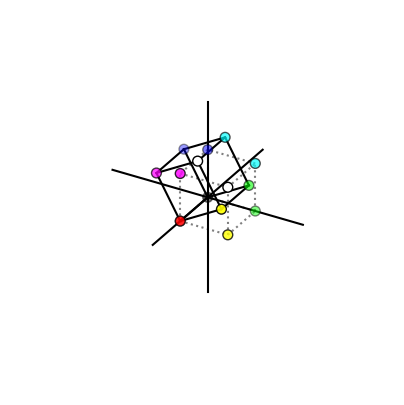

In [17]:
fig = plt.figure(figsize = (5,5))
ax = fig.add_subplot(111,projection = '3d')

theta_1 = np.pi/6
R_x1 = np.array([[1,0,0],
                 [0,np.cos(theta_1),-np.sin(theta_1)],
                 [0,np.sin(theta_1),np.cos(theta_1)]])

rotated_cube = cube @ R_x1.T
plot_cube(ax,cube,rotated_cube)

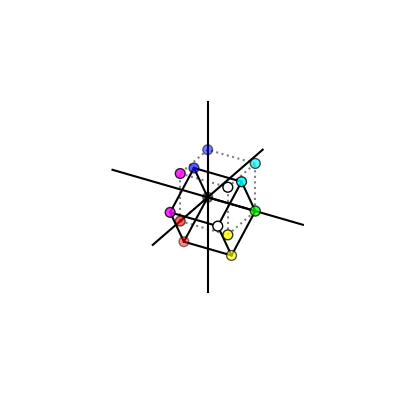

In [19]:
fig = plt.figure(figsize = (5,5))
ax = fig.add_subplot(111,projection = '3d')

theta_2 = np.pi/6
R_x2 = np.array([[np.cos(theta_2),0,np.sin(theta_2)],
                 [0,1,0],
                 [-np.sin(theta_2),0,np.cos(theta_2)]])

rotated_cube = cube @ R_x2.T
plot_cube(ax,cube,rotated_cube)

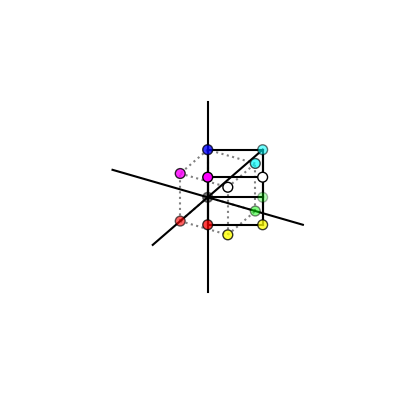

In [23]:
fig = plt.figure(figsize = (5,5))
ax = fig.add_subplot(111,projection = '3d')

theta_3 = np.pi/6
R_x3 = np.array([[np.cos(theta_3),-np.sin(theta_3),0],
                 [np.sin(theta_3),np.cos(theta_3),0],
                 [0,0,1]])

rotated_cube = cube @ R_x3.T
plot_cube(ax,cube,rotated_cube)